## Data uploading and analysis

In [1]:
# ============================================
# Platelet RNA-seq Cancer Type Analysis
# Author: Reyad Aly
# Date: 05/07/2026
# GitHub: github.com/ReyadAly
# LinkedIn: https://www.linkedin.com/in/reyad-aly/

# This project is licensed under CC BY 4.0
# Any reuse must credit the original author
# ============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GSE68086_TEP_data_matrix.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57736 entries, 0 to 57735
Columns: 286 entries, Unnamed: 0 to MGH-NSCLC-L65-TR523
dtypes: int64(285), object(1)
memory usage: 126.0+ MB


In [3]:
df.isnull().sum()

Unnamed: 0             0
3-Breast-Her2-ampl     0
8-Breast-WT            0
10-Breast-Her2-ampl    0
Breast-100             0
                      ..
MGH-NSCLC-L40-TR520    0
MGH-NSCLC-L51-TR521    0
MGH-NSCLC-L58-TR525    0
MGH-NSCLC-L59-TR522    0
MGH-NSCLC-L65-TR523    0
Length: 286, dtype: int64

In [4]:
df.describe()

,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,Breast-454,...,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
count,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,...,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000,57736.000000
mean,67.509336,60.334505,57.458137,17.791932,47.077681,43.912031,48.680165,48.982368,45.717490,17.802134,...,31.153041,25.659571,43.689552,39.376039,55.000797,20.734741,37.403544,50.038053,21.575793,45.779566
std,2397.767059,1901.744001,1787.716033,642.109828,1682.553076,1620.265040,1365.433530,1692.852382,1355.855294,773.132949,...,749.567988,600.580620,922.497209,894.419800,1346.105928,601.927062,993.250896,1073.798413,586.500669,1182.551215
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,455636.000000,287079.000000,289755.000000,102324.000000,274821.000000,336855.000000,273575.000000,323705.000000,247464.000000,156771.000000,...,102273.000000,98009.000000,113542.000000,130442.000000,179488.000000,95842.000000,132807.000000,144572.000000,102096.000000,152978.000000


##  Data visualization

In [5]:
#Renaming gene column
df = df.rename(columns={"Unnamed: 0": "Gene"})
df.set_index("Gene", inplace=True)

In [6]:
#transposing
df_T = df.T  
df_T.index.name = "Sample"

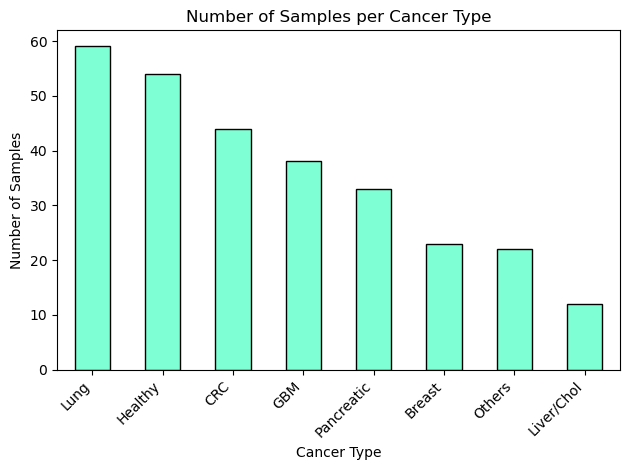

In [7]:
#Bar Chart: Number of Samples per Cancer Type - Extracting labels from sample names
def get_cancer_type(sample_name):
    if "Breast" in sample_name:
        return "Breast"
    elif "CRC" in sample_name:
        return "CRC"
    elif "GBM" in sample_name:
        return "GBM"
    elif "HD" in sample_name or "Control" in sample_name:
        return "Healthy"
    elif "Lung" in sample_name or "NSCLC" in sample_name:
        return "Lung"
    elif "Pancr" in sample_name or "Panc" in sample_name:
        return "Pancreatic"
    elif "Liver" in sample_name or "Chol" in sample_name:
        return "Liver/Chol"
    else:
        return "Others"
   
df_T["Cancer Types"] = df_T.index.map(get_cancer_type)
df_T["Cancer Types"].value_counts()
df_T["Cancer Types"].value_counts().plot(kind="bar", color="aquamarine", edgecolor="black")
plt.title("Number of Samples per Cancer Type")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [8]:
#Finding top expressed gene for Breast cancer
avg_expr = df_T.groupby("Cancer Types").mean()
top_breast = avg_expr.loc["Breast"].sort_values(ascending=False).head(10)
top_breast

Gene
ENSG00000166710    237342.086957
ENSG00000163736    137900.956522
ENSG00000205542     85129.304348
ENSG00000124491     65435.000000
ENSG00000075624     51472.565217
ENSG00000120885     47239.043478
ENSG00000087086     35780.826087
ENSG00000113140     35253.130435
ENSG00000161570     28600.217391
ENSG00000228474     26959.956522
Name: Breast, dtype: float64

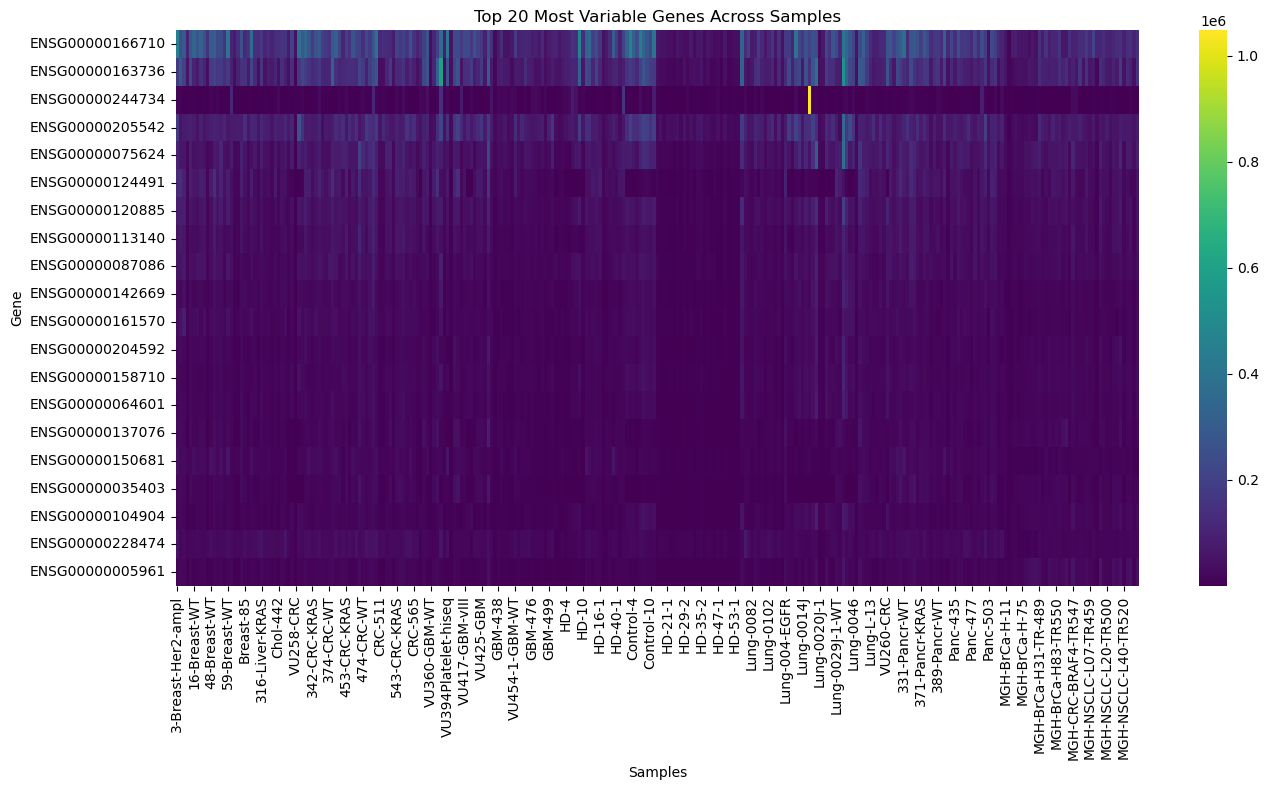

In [9]:
#Heatmap: Top 20 Most Variable Genes (Expression levels)
gene_variance = df.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(20).index

plt.figure(figsize=(14, 8))
sns.heatmap(df.loc[top_genes], cmap="viridis", yticklabels=True)
plt.title("Top 20 Most Variable Genes Across Samples")
plt.xlabel("Samples")
plt.tight_layout()

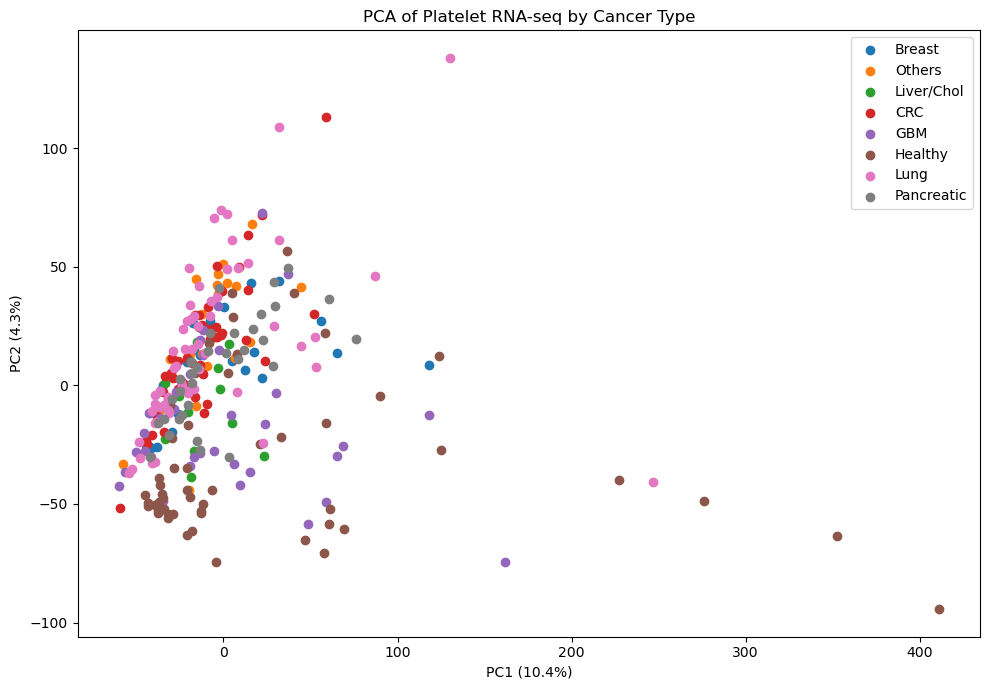

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Dropping cancer types column to avoid crashing due to presence of text in PCA
X = df_T.drop(columns=["Cancer Types"])
labels = df_T["Cancer Types"]

#scaling PCA (to make all genes on equal footing)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# PCA Scatter Plot: Cancer Type Clustering
pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df["Cancer Types"] = labels.values

plt.figure(figsize=(10, 7))
for cancer in pca_df["Cancer Types"].unique():
    subset = pca_df[pca_df["Cancer Types"] == cancer]
    plt.scatter(subset["PC1"], subset["PC2"], label=cancer)
plt.legend()
plt.title("PCA of Platelet RNA-seq by Cancer Type")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()

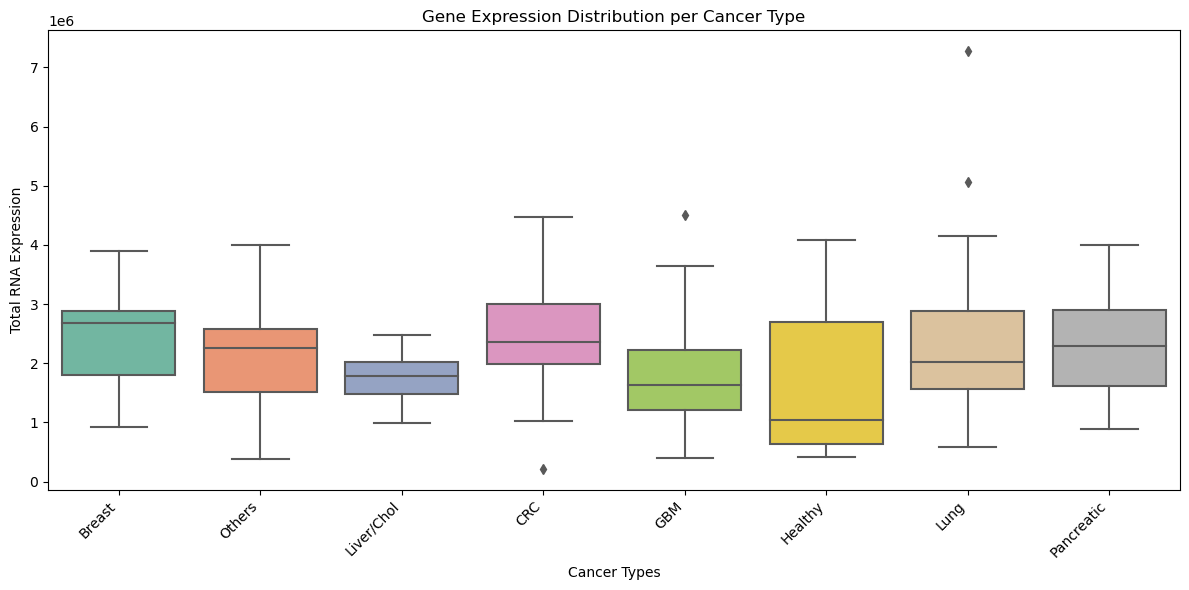

In [11]:
#Getting total exppresion per sample
df_T["Total Expression"] = df_T.drop(columns=["Cancer Types"]).sum(axis=1)

#Boxplot: Expression Distribution per cancer type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_T, x="Cancer Types", y="Total Expression", palette="Set2")
plt.xticks(rotation=45, ha='right')
plt.title("Gene Expression Distribution per Cancer Type")
plt.ylabel("Total RNA Expression")
plt.tight_layout()

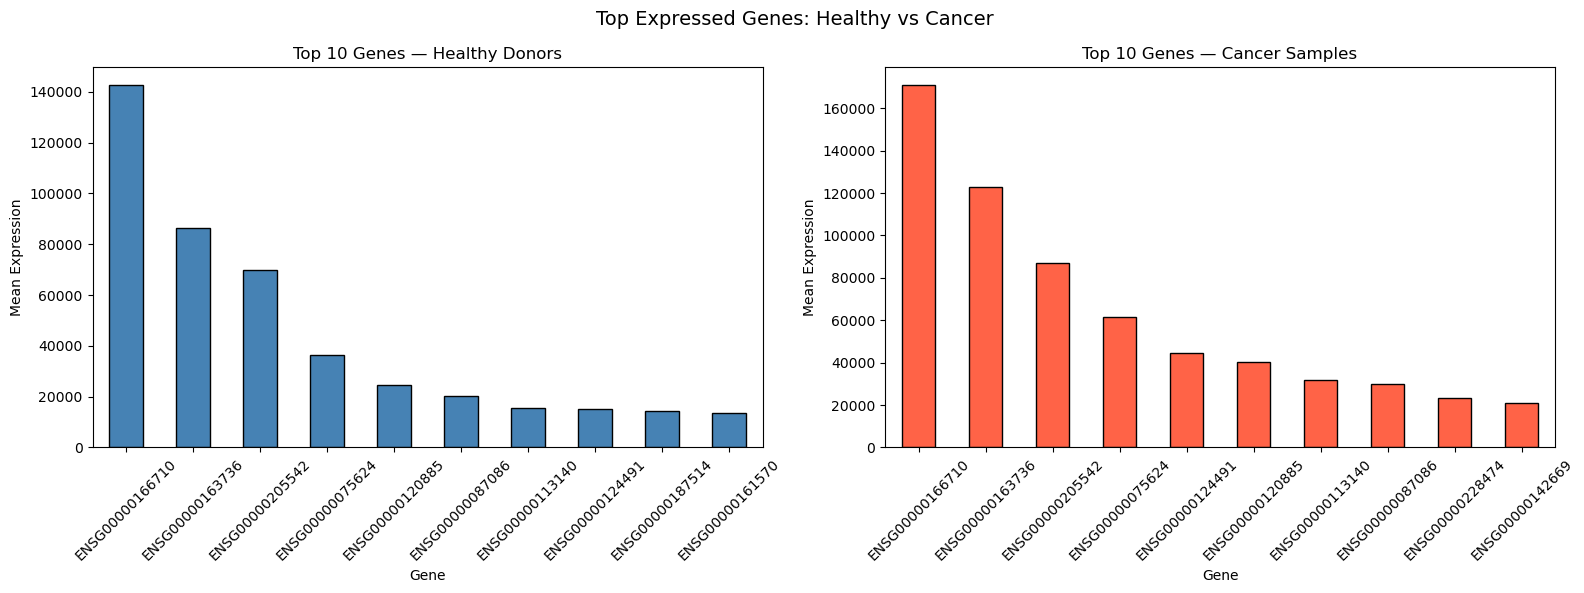

In [12]:
#Seperation between health and unhealthy
healthy = df_T[df_T["Cancer Types"] == "Healthy"].drop(columns=["Cancer Types", "Total Expression"])
cancer = df_T[df_T["Cancer Types"] != "Healthy"].drop(columns=["Cancer Types", "Total Expression"])

#Highest Expressed Genes in "Healthy vs Cancer" categories
healthy_mean = healthy.mean().sort_values(ascending=False).head(10)
cancer_mean = cancer.mean().sort_values(ascending=False).head(10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

healthy_mean.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Top 10 Genes — Healthy Donors")
axes[0].set_ylabel("Mean Expression")
axes[0].tick_params(axis='x', rotation=45)

cancer_mean.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Top 10 Genes — Cancer Samples")
axes[1].set_ylabel("Mean Expression")
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle("Top Expressed Genes: Healthy vs Cancer", fontsize=14)
plt.tight_layout()